In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)
df = pd.read_csv('../data/diabetic_data.csv')

First, some high-level exploratory analysis of the data. Just looking for distributions of variables at this point - patient counts and readmission rates

In [3]:
df['readmitted_dummy'] = (df['readmitted']!='NO')*1

In [4]:
def count_all_diag(df):
    diag = pd.concat([df['diag_1'].drop_duplicates(),df['diag_2'].drop_duplicates(),df['diag_3'].drop_duplicates()]).drop_duplicates().reset_index()
    diag.columns = ['index','diag']
    diag = diag.drop('index',axis=1)

    for i in range(1,4):
        diag_df = df.groupby(f'diag_{i}').count()['encounter_id']
        diag_df = diag_df.reset_index()
        diag_df.columns = ['diag',f'diag_{i}_ct']
        diag = pd.merge(diag, diag_df,on='diag',how='left')
    
    diag = diag.fillna(0)
    diag['total_ct'] = diag['diag_1_ct'] + diag['diag_2_ct'] + diag['diag_3_ct']
    return diag

In [5]:
icd9 = pd.read_csv("../data/icd9.txt",sep='\t',encoding='mbcs')
icd9.columns = ['diagnosis','long','short','other']
icd9.drop('other',inplace=True,axis=1)

diag = count_all_diag(df)

In [6]:
#TODO: Check against adding 0
diag['diagnosis'] = diag['diag'].str.replace(r'[^a-zA-Z0-9]','',regex=True)
diag = pd.merge(diag,icd9,on='diagnosis',how='left')
diag = diag.sort_values('total_ct',ascending=False)

In [7]:
# diag.iloc[:100].loc[:,['diag','total_ct']].to_csv('frontend/valid_diag.csv',index=False)

In [8]:
# df['race'].drop_duplicates().to_csv('frontend/valid_race.csv',index=False)
# df['age'].drop_duplicates().to_csv('frontend/valid_age.csv',index=False)
# df['gender'].drop_duplicates().to_csv('frontend/valid_gender.csv',index=False)

In [9]:
#Would want to add unit tests here - pass in dummy dataframe, pass in dummy dataframe + grouping
def calculate_readmitted_rate(df, grouping=None):
    if grouping:
        rate = df.groupby(grouping).agg({'patient_nbr':'count', 'readmitted_dummy':'sum'})
        rate['readmitted_rate'] = rate['readmitted_dummy']/rate['patient_nbr']
    else:
        rate = df['readmitted_dummy'].sum()/df['patient_nbr'].count()
    return rate

In [12]:
import numpy as np

def parse_weight(x):
    if x == '>200':
        return 200
    else:
        weights = [int(i) for i in x[1:-1].split('-')]
        return np.mean(weights)
    
#Only about 3% of the 100K rows have weight populated - it may be important for those patients but we probably shouldn't impute for remaining.
#I also wonder about the validity of the data that we do have - [0,25) for a 60-70 year old woman is clearly wrong
#Lastly, I'm going to convert these from ranges to the midpoints so they are sortable
has_weight = df[df['weight']!='?']
has_weight['weight_parsed'] = has_weight['weight'].apply(parse_weight)
weight_readmission = calculate_readmitted_rate(has_weight,['gender','weight_parsed'])
display(weight_readmission)

patient_nbr  readmitted_dummy  readmitted_rate
gender weight_parsed                                                
Female 12.5                    22                16         0.727273
       37.5                    71                38         0.535211
       62.5                   595               331         0.556303
       87.5                   633               380         0.600316
       112.5                  242               139         0.574380
       137.5                   60                31         0.516667
       162.5                   18                 8         0.444444
       187.5                    5                 2         0.400000
       200.0                    2                 2         1.000000
Male   12.5                    26                23         0.884615
       37.5                    26                12         0.461538
       62.5                   302               163         0.539735
       87.5                   703               436         0.620199
       112.5                  383               220         0.574413
       137.5                   85                50         0.588235
       162.5                   17                11         0.647059
       187.5                    6                 4         0.666667
       200.0                    1                 1         1.000000

In [13]:
high_level_aggregations = ['race','gender','age']

for i in high_level_aggregations:
    df_agg = calculate_readmitted_rate(df, i)
    display(df_agg)

,patient_nbr,readmitted_dummy,readmitted_rate
race,,,
?,2273,726,0.319402
AfricanAmerican,19210,8789,0.457522
Asian,641,226,0.352574
Caucasian,76099,35716,0.469336
Hispanic,2037,854,0.419244
Other,1506,591,0.392430


,patient_nbr,readmitted_dummy,readmitted_rate
gender,,,
Female,54708,25670,0.469218
Male,47055,21232,0.451217
Unknown/Invalid,3,0,0.000000


,patient_nbr,readmitted_dummy,readmitted_rate
age,,,
[0-10),161,29,0.180124
[10-20),691,264,0.382055
[20-30),1657,746,0.450211
[30-40),3775,1611,0.426755
[40-50),9685,4305,0.444502
[50-60),17256,7585,0.439557
[60-70),22483,10399,0.462527
[70-80),26068,12544,0.481203
[80-90),17197,8301,0.482700


Some initial notes:
* Caucasian has a higher rate of readmission than African Ameircan. Hispanic and Asian have lower rates, but also much lower populations
* Female have a slightly higher rate of readmission than male
* Age tends to be correlated positively with readmission until 90-100

In [14]:
from resample.bootstrap import resample
from resample.bootstrap import confidence_interval

#Bootstrapping shows us that these populations are likely statistically different, although the upper end of African American and lower end of Caucasian are very close
for race in df['race'].drop_duplicates():
    race_df = df[df['race']==race]
    race_ci = confidence_interval(np.mean, race_df['readmitted_dummy'])
    print(f'Bootstrapped 95% CI for {race}: {race_ci[0]:0.3f} to {race_ci[1]:0.3f}')

Bootstrapped 95% CI for Caucasian: 0.466 to 0.473
Bootstrapped 95% CI for AfricanAmerican: 0.451 to 0.467
Bootstrapped 95% CI for ?: 0.295 to 0.337
Bootstrapped 95% CI for Other: 0.369 to 0.434
Bootstrapped 95% CI for Asian: 0.306 to 0.396
Bootstrapped 95% CI for Hispanic: 0.390 to 0.442


Some data cleanliness checks:
* Do any of the patients repeat? - Yes, 16,773
* Do any of the encounters repeat? - No

In [15]:
repeat_patients = df.groupby('patient_nbr').count()
repeat_patients = repeat_patients[repeat_patients['encounter_id']>1]
repeats = repeat_patients.count()['encounter_id']
print(f'There are {repeats} repeat patients')

example_repeat = repeat_patients.iloc[0]

There are 16773 repeat patients


In [16]:
repeat_encounters = df.groupby('encounter_id').count()
repeat_encounters = repeat_encounters[repeat_encounters['patient_nbr']>1]
repeats = repeat_encounters.count()['patient_nbr']
print(f'There are {repeats} repeat encounters')

There are 0 repeat encounters


What do I do with the repeat patients? There's no date in this data so we can't be sure there wouldn't be data leakage. We also don't know if encounter_id is monotonic with date, it's possible that earlier encounters have higher ids

In [17]:
display(df[df['patient_nbr']==example_repeat.name])

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_dummy
4267,24437208,135,Caucasian,Female,[50-60),?,2,1,1,8,?,Cardiology,77,6,33,0,0,0,401,997,560,8,NaN,NaN,Steady,No,No,No,No,No,No,Down,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,<30,1
4780,26264286,135,Caucasian,Female,[50-60),?,1,1,7,3,?,Surgery-Cardiovascular/Thoracic,31,1,14,0,0,1,998,41,250,5,NaN,NaN,Steady,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,>30,1


How do I do this?
SELECT
    patient_nbr,
    COUNT(encounter_id) OVER(PARTITION BY patient_nbr ORDER BY encounter_id ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS Prior_Admissions
FROM
    df

In [18]:
df['prior_readmissions'] = df.sort_values(['patient_nbr','encounter_id']).groupby('patient_nbr').cumcount()

In [19]:
df[df['patient_nbr']==31693671]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_dummy,prior_readmissions
61356,171362400,31693671,Caucasian,Female,[80-90),?,1,22,7,6,MC,Emergency/Trauma,59,3,19,0,0,0,820,424,250.02,4,NaN,>7,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30,1,0
74156,220587978,31693671,Caucasian,Female,[80-90),?,2,3,7,8,MC,Emergency/Trauma,60,0,10,0,0,1,428,424,414,6,NaN,>8,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30,1,1
82094,255395892,31693671,Caucasian,Female,[80-90),?,2,2,7,5,MC,Emergency/Trauma,52,3,15,0,0,1,428,424,53,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,1,2
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,3


In [20]:
#Strong trend for future admissions based on number of prior readmissions
calculate_readmitted_rate(df,['prior_readmissions'])

,patient_nbr,readmitted_dummy,readmitted_rate
prior_readmissions,,,
0,71518,28533,0.398962
1,16773,9176,0.547070
2,6339,4024,0.634800
3,3011,2057,0.683162
4,1590,1108,0.696855
5,873,647,0.741123
6,527,393,0.745731
7,320,258,0.806250
8,209,173,0.827751


In [21]:
#These patients passed away after being discharged - we can set them aside since they won't be readmitted
expired = df[df['discharge_disposition_id'].isin([11,19,20,21])]
alive = df[~df['discharge_disposition_id'].isin([11,19,20,21])]

In [22]:
alive

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_dummy,prior_readmissions
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0,0
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,1,0
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0,0
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,0
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30,1,1
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO,0,1
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO,0,2
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0,3


In [23]:
def convert_medicine_columns(x):
    if x=='No':
        return 0
    elif x in ['Down','Up','Steady']:
        return 1
    else:
        raise ValueError(x)

medicine_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
   'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
   'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
   'tolazamide', 'examide', 'citoglipton', 'insulin',
   'glyburide-metformin', 'glipizide-metformin',
   'glimepiride-pioglitazone', 'metformin-rosiglitazone',
   'metformin-pioglitazone']

for m in medicine_columns:
    alive[f'on_{m}'] = alive[m].apply(convert_medicine_columns)
    display(calculate_readmitted_rate(alive,m))

,patient_nbr,readmitted_dummy,readmitted_rate
metformin,,,
Down,575,259,0.450435
No,80216,38257,0.476925
Steady,18256,7951,0.435528
Up,1067,435,0.407685


,patient_nbr,readmitted_dummy,readmitted_rate
repaglinide,,,
Down,45,22,0.488889
No,98587,46057,0.467171
Steady,1373,770,0.560816
Up,109,53,0.486239


,patient_nbr,readmitted_dummy,readmitted_rate
nateglinide,,,
Down,11,5,0.454545
No,99419,46560,0.468321
Steady,660,326,0.493939
Up,24,11,0.458333


,patient_nbr,readmitted_dummy,readmitted_rate
chlorpropamide,,,
Down,1,0,0.000000
No,100029,46863,0.468494
Steady,78,34,0.435897
Up,6,5,0.833333


,patient_nbr,readmitted_dummy,readmitted_rate
glimepiride,,,
Down,193,93,0.481865
No,94967,44465,0.468215
Steady,4630,2205,0.476242
Up,324,139,0.429012


,patient_nbr,readmitted_dummy,readmitted_rate
acetohexamide,,,
No,100113,46901,0.468481
Steady,1,1,1.000000


,patient_nbr,readmitted_dummy,readmitted_rate
glipizide,,,
Down,554,296,0.534296
No,87509,40720,0.465324
Steady,11284,5501,0.487504
Up,767,385,0.501956


,patient_nbr,readmitted_dummy,readmitted_rate
glyburide,,,
Down,561,275,0.490196
No,89547,42052,0.469608
Steady,9200,4216,0.458261
Up,806,359,0.445409


,patient_nbr,readmitted_dummy,readmitted_rate
tolbutamide,,,
No,100093,46894,0.468504
Steady,21,8,0.380952


,patient_nbr,readmitted_dummy,readmitted_rate
pioglitazone,,,
Down,117,63,0.538462
No,92833,43371,0.467194
Steady,6934,3347,0.482694
Up,230,121,0.526087


,patient_nbr,readmitted_dummy,readmitted_rate
rosiglitazone,,,
Down,86,27,0.313953
No,93785,43828,0.467324
Steady,6070,2976,0.490280
Up,173,71,0.410405


,patient_nbr,readmitted_dummy,readmitted_rate
acarbose,,,
Down,3,2,0.666667
No,99807,46719,0.468093
Steady,294,175,0.595238
Up,10,6,0.600000


,patient_nbr,readmitted_dummy,readmitted_rate
miglitol,,,
Down,5,5,1.000000
No,100076,46878,0.468424
Steady,31,18,0.580645
Up,2,1,0.500000


,patient_nbr,readmitted_dummy,readmitted_rate
troglitazone,,,
No,100111,46900,0.468480
Steady,3,2,0.666667


,patient_nbr,readmitted_dummy,readmitted_rate
tolazamide,,,
No,100075,46889,0.468539
Steady,38,12,0.315789
Up,1,1,1.000000


,patient_nbr,readmitted_dummy,readmitted_rate
examide,,,
No,100114,46902,0.468486


,patient_nbr,readmitted_dummy,readmitted_rate
citoglipton,,,
No,100114,46902,0.468486


,patient_nbr,readmitted_dummy,readmitted_rate
insulin,,,
Down,12012,6450,0.536963
No,46680,20705,0.443552
Steady,30331,13915,0.458772
Up,11091,5832,0.525832


,patient_nbr,readmitted_dummy,readmitted_rate
glyburide-metformin,,,
Down,6,1,0.166667
No,99416,46566,0.468395
Steady,684,334,0.488304
Up,8,1,0.125000


,patient_nbr,readmitted_dummy,readmitted_rate
glipizide-metformin,,,
No,100101,46894,0.468467
Steady,13,8,0.615385


,patient_nbr,readmitted_dummy,readmitted_rate
glimepiride-pioglitazone,,,
No,100113,46901,0.468481
Steady,1,1,1.000000


,patient_nbr,readmitted_dummy,readmitted_rate
metformin-rosiglitazone,,,
No,100112,46902,0.468495
Steady,2,0,0.000000


,patient_nbr,readmitted_dummy,readmitted_rate
metformin-pioglitazone,,,
No,100113,46902,0.468491
Steady,1,0,0.000000


In [24]:
on_medicine = ['on_' + m for m in medicine_columns]
alive['number_of_diabetes_medications'] = alive[on_medicine].sum(axis=1)

In [25]:
for m in on_medicine:
    display(calculate_readmitted_rate(alive,m))

,patient_nbr,readmitted_dummy,readmitted_rate
on_metformin,,,
0,80216,38257,0.476925
1,19898,8645,0.434466


,patient_nbr,readmitted_dummy,readmitted_rate
on_repaglinide,,,
0,98587,46057,0.467171
1,1527,845,0.553373


,patient_nbr,readmitted_dummy,readmitted_rate
on_nateglinide,,,
0,99419,46560,0.468321
1,695,342,0.492086


,patient_nbr,readmitted_dummy,readmitted_rate
on_chlorpropamide,,,
0,100029,46863,0.468494
1,85,39,0.458824


,patient_nbr,readmitted_dummy,readmitted_rate
on_glimepiride,,,
0,94967,44465,0.468215
1,5147,2437,0.473480


,patient_nbr,readmitted_dummy,readmitted_rate
on_acetohexamide,,,
0,100113,46901,0.468481
1,1,1,1.000000


,patient_nbr,readmitted_dummy,readmitted_rate
on_glipizide,,,
0,87509,40720,0.465324
1,12605,6182,0.490440


,patient_nbr,readmitted_dummy,readmitted_rate
on_glyburide,,,
0,89547,42052,0.469608
1,10567,4850,0.458976


,patient_nbr,readmitted_dummy,readmitted_rate
on_tolbutamide,,,
0,100093,46894,0.468504
1,21,8,0.380952


,patient_nbr,readmitted_dummy,readmitted_rate
on_pioglitazone,,,
0,92833,43371,0.467194
1,7281,3531,0.484961


,patient_nbr,readmitted_dummy,readmitted_rate
on_rosiglitazone,,,
0,93785,43828,0.467324
1,6329,3074,0.485701


,patient_nbr,readmitted_dummy,readmitted_rate
on_acarbose,,,
0,99807,46719,0.468093
1,307,183,0.596091


,patient_nbr,readmitted_dummy,readmitted_rate
on_miglitol,,,
0,100076,46878,0.468424
1,38,24,0.631579


,patient_nbr,readmitted_dummy,readmitted_rate
on_troglitazone,,,
0,100111,46900,0.468480
1,3,2,0.666667


,patient_nbr,readmitted_dummy,readmitted_rate
on_tolazamide,,,
0,100075,46889,0.468539
1,39,13,0.333333


,patient_nbr,readmitted_dummy,readmitted_rate
on_examide,,,
0,100114,46902,0.468486


,patient_nbr,readmitted_dummy,readmitted_rate
on_citoglipton,,,
0,100114,46902,0.468486


,patient_nbr,readmitted_dummy,readmitted_rate
on_insulin,,,
0,46680,20705,0.443552
1,53434,26197,0.490268


,patient_nbr,readmitted_dummy,readmitted_rate
on_glyburide-metformin,,,
0,99416,46566,0.468395
1,698,336,0.481375


,patient_nbr,readmitted_dummy,readmitted_rate
on_glipizide-metformin,,,
0,100101,46894,0.468467
1,13,8,0.615385


,patient_nbr,readmitted_dummy,readmitted_rate
on_glimepiride-pioglitazone,,,
0,100113,46901,0.468481
1,1,1,1.000000


,patient_nbr,readmitted_dummy,readmitted_rate
on_metformin-rosiglitazone,,,
0,100112,46902,0.468495
1,2,0,0.000000


,patient_nbr,readmitted_dummy,readmitted_rate
on_metformin-pioglitazone,,,
0,100113,46902,0.468491
1,1,0,0.000000


In [26]:
display(calculate_readmitted_rate(alive,'number_of_diabetes_medications'))

,patient_nbr,readmitted_dummy,readmitted_rate
number_of_diabetes_medications,,,
0,22842,9473,0.414719
1,46433,23003,0.495402
2,21714,10207,0.470065
3,7737,3602,0.465555
4,1325,594,0.448302
5,58,19,0.327586
6,5,4,0.800000


In [27]:
display(calculate_readmitted_rate(alive,'number_diagnoses'))

,patient_nbr,readmitted_dummy,readmitted_rate
number_diagnoses,,,
1,219,52,0.237443
2,1021,336,0.329089
3,2824,972,0.344193
4,5509,2063,0.374478
5,11323,4039,0.356708
6,10043,4455,0.443593
7,10271,4851,0.472301
8,10430,5052,0.484372
9,48363,25026,0.517462


In [28]:
alive.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'readmitted_dummy', 'prior_readmissions', 'on_metformin',
       'on_repaglinide', 'o

In [29]:
icd9['first_three'] = icd9['diagnosis'].str[0:3]
icd9['long_tokenized'] = icd9['long'].str.replace('[^a-zA-Z0-9\s]','',regex=True).str.split(' ')

representative_term_first = icd9.sort_values(['first_three','diagnosis']).groupby('first_three').first()['long'].reset_index()
representative_term_first.columns = ['first_three','representative_term_first']
icd9=pd.merge(icd9,representative_term_first,on='first_three')

for i in icd9['first_three'].drop_duplicates():
    to_agg = icd9.loc[icd9['first_three']==i,['long_tokenized']]
    term_counts = to_agg.explode('long_tokenized').dropna().value_counts()
    if len(term_counts.index) > 1:
        max_term = term_counts.index[0][0] + ' ' + term_counts.index[1][0]
    else:
        max_term = term_counts.index[0][0]
    icd9.loc[icd9['first_three']==i,'representative_term']=max_term
    
rep_term = icd9[['first_three','representative_term_first']].drop_duplicates()

alive['first_three'] = alive['diag_1'].str[0:3]
alive = pd.merge(alive, rep_term, on=['first_three'],how='left')
alive['random'] = np.random.rand(alive.shape[0],1)

In [30]:
features_to_use = ['race', 'gender', 'age','admission_type_id',
                   'discharge_disposition_id', 'admission_source_id','time_in_hospital',
                   'num_lab_procedures', 'num_procedures', 'num_medications',
                   'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
                   'diag_2', 'diag_3', 'number_diagnoses','number_of_diabetes_medications',
                   'prior_readmissions','readmitted_dummy'
                  ]
full_feature_df = alive[features_to_use]

In [31]:
alive[features_to_use]

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,number_of_diabetes_medications,prior_readmissions,readmitted_dummy
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,?,?,1,0,0,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,1,0,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,1,0,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,1,0,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100109,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,16,0,0,0,250.13,291,458,9,2,1,1
100110,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,18,0,0,1,560,276,787,9,1,1,0
100111,Caucasian,Male,[70-80),1,1,7,1,53,0,9,1,0,0,38,590,296,13,2,2,0
100112,Caucasian,Female,[80-90),2,3,7,10,45,2,21,0,0,1,996,285,998,9,3,3,0


Model exploration

In [32]:
# pd.get_dummies(full_feature_df,columns=['race','gender','age'])

In [33]:
from sklearn.model_selection import train_test_split

X_cols = [c for c in features_to_use if c != 'readmitted_dummy']
X = full_feature_df[X_cols]
y = full_feature_df['readmitted_dummy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [34]:
category_types = ['race','gender','age','diag_1','diag_2','diag_3']#,'representative_term_first']
for c in category_types:
    X_train[c] = X_train[c].astype('category')
    X_test[c] = X_test[c].astype('category')

In [35]:
mini_features = ['diag_1','diag_2','diag_3','number_inpatient','admission_source_id','age','num_medications']

X_train_mini = X_train.loc[:,mini_features]
X_test_mini = X_test.loc[:,mini_features]

In [36]:
import xgboost as xgb

params = {
    'n_estimators':1000,
    "objective": "binary:logistic",
    "eval_metric": "auc",
}
#     "eta": 0.01,
    
#     "subsample": 0.5,
#     "base_score": np.mean(y_train),
    
# }

# d_train = xgb.DMatrix(X_train_mini, label=y_train,enable_categorical=True,)
# d_test = xgb.DMatrix(X_test_mini, label=y_test,enable_categorical=True,)

X_train_to_use = X_train
X_test_to_use = X_test

clf = xgb.XGBClassifier(**params,
                        enable_categorical=True,
                        verbosity=1,
                        device="cuda")
clf.fit(X_train_to_use, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [37]:
y_pred = clf.predict(X_test_to_use)

C:\Users\richw\PycharmProjects\readmission\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [19:54:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [38]:
from sklearn import metrics as m

print(m.confusion_matrix(y_test,y_pred))
print(m.precision_score(y_test, y_pred))
print(m.recall_score(y_test, y_pred))

[[11340  6230]
 [ 6932  8536]]
0.5780847893810104
0.5518489785363331


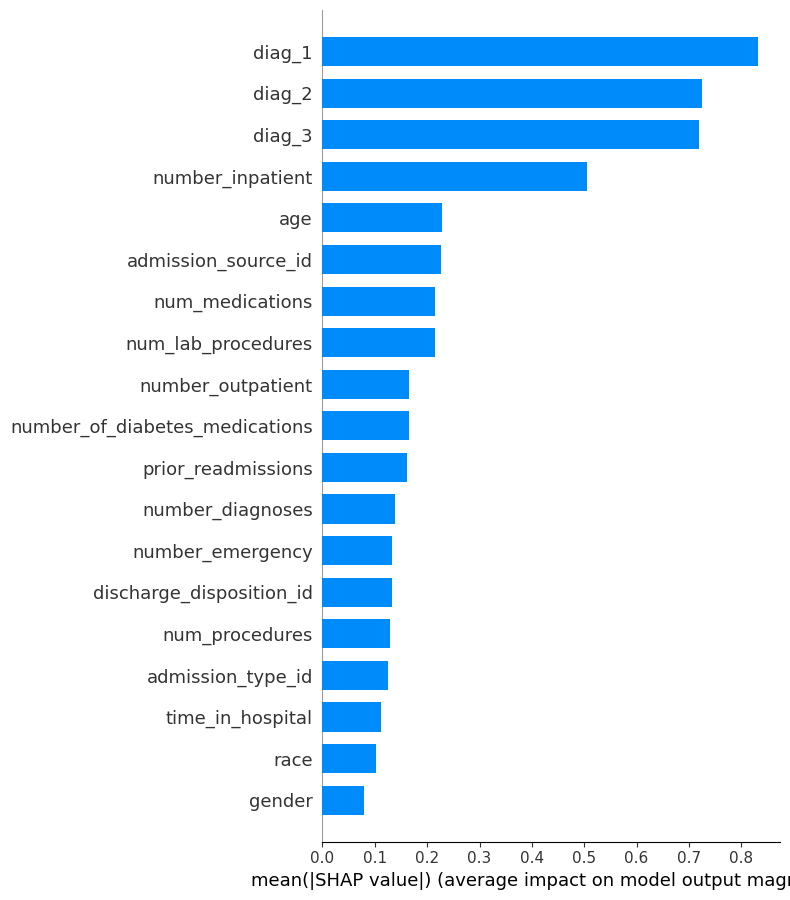

In [39]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_train_to_use, check_additivity=False)

shap.summary_plot(shap_values, X_train_to_use, plot_type="bar")

In [40]:
probs = clf.predict_proba(X_test_to_use)[:,1]

In [41]:
# from joblib import dump, load

# dump(clf, 'models/xgboost_uncalibrated.joblib')

FileNotFoundError: [Errno 2] No such file or directory: 'models/xgboost_uncalibrated.joblib'

In [42]:
y_test_df = pd.DataFrame(y_test)
y_test_df['confidence'] = probs
y_test_df['decile'] = y_test_df['confidence']*100//10
y_test_df['count'] = 1

In [43]:
calibration = y_test_df.groupby('decile').agg({'count':'sum','confidence':'mean','readmitted_dummy':'sum'})
total_count = calibration['count'].sum()
calibration['accuracy'] = calibration['readmitted_dummy']/calibration['count']
calibration['percent_of_total'] = calibration['count']/total_count

In [44]:
calibration['calibration_metric'] = calibration['percent_of_total']*np.abs(calibration['accuracy']-calibration['confidence'])

In [45]:
print(calibration['calibration_metric'].sum())

0.20634236710186776


In [46]:
import calibration as cal
calibration_error = cal.get_calibration_error(clf.predict_proba(X_test_to_use), y_test)

In [47]:
calibration_error

np.float64(0.22449969995017954)

In [48]:
def expected_calibration_error(samples, true_labels, M=5):
    # uniform binning approach with M number of bins
    bin_boundaries = np.linspace(0, 1, M + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    # get max probability per sample i
    confidences = np.max(samples, axis=1)
    # get predictions from confidences (positional in this case)
    predicted_label = np.argmax(samples, axis=1)

    # get a boolean list of correct/false predictions
    accuracies = predicted_label==true_labels

    ece = np.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # determine if sample is in bin m (between bin lower & upper)
        in_bin = np.logical_and(confidences > bin_lower.item(), confidences <= bin_upper.item())
        # can calculate the empirical probability of a sample falling into bin m: (|Bm|/n)
        prob_in_bin = in_bin.mean()

        if prob_in_bin.item() > 0:
            # get the accuracy of bin m: acc(Bm)
            accuracy_in_bin = accuracies[in_bin].mean()
            # get the average confidence of bin m: conf(Bm)
            avg_confidence_in_bin = confidences[in_bin].mean()
            # calculate |acc(Bm) - conf(Bm)| * (|Bm|/n) for bin m and add to the total ECE
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prob_in_bin
    return ece

expected_calibration_error(clf.predict_proba(X_test_to_use), y_test,10)

array([0.20634234])

0.28482040762901306


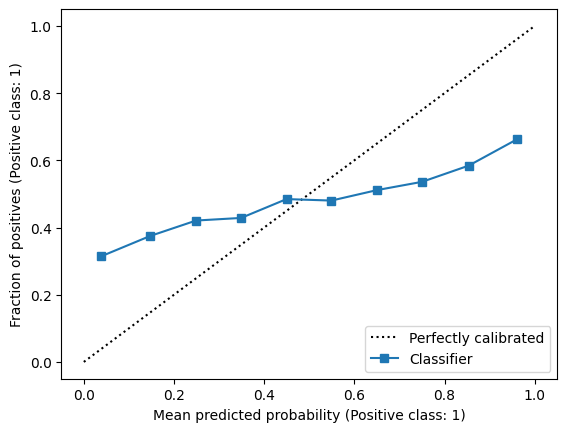

In [49]:
from sklearn.calibration import calibration_curve, CalibrationDisplay

prob_pos = clf.predict_proba(X_test_to_use)[:, 1]
true = y_test
CalibrationDisplay.from_predictions(true, prob_pos, n_bins=10)

from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, prob_pos)
print(brier)

In [50]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(clf, method='isotonic', cv=5)
calibrated_model.fit(X_train_to_use, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[fl

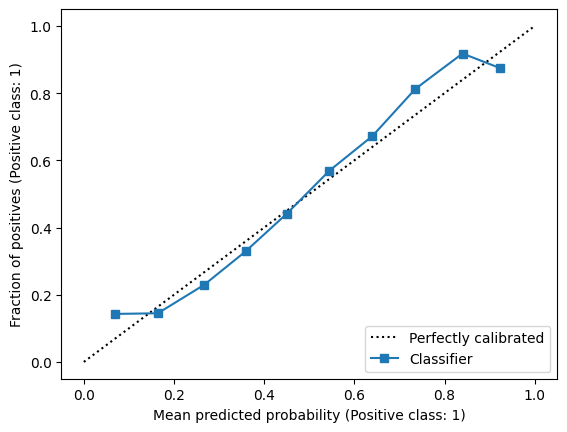

In [51]:
prob_pos = calibrated_model.predict_proba(X_test_to_use)[:, 1]
true = y_test
CalibrationDisplay.from_predictions(true, prob_pos, n_bins=10)

In [52]:
from sklearn import metrics as m

y_pred_calibrated = calibrated_model.predict(X_test_to_use)
print(m.confusion_matrix(y_test,y_pred_calibrated))
print(m.precision_score(y_test, y_pred_calibrated))
print(m.recall_score(y_test, y_pred_calibrated))

[[12789  4781]
 [ 7895  7573]]
0.6129998381091144
0.4895914145332299


In [49]:
from joblib import dump, load

dump(calibrated_model, 'models/calibrated_model.joblib')

['models/calibrated_model.joblib']

In [371]:
#Increased precision, lowered recall - Meaning we're missing more positives than we used to, but when we say something is positive we're correct more often
#Also note we're predicting fewer things are positive to begin with
#Precision = Number of true positives/all labeled positives
#Recall = Number of true positives/all positives

TODO:
* Clean up diag1, diag2, diag3 to add in 'UNK' category to account for where we haven't seen classes before
* Parse valid age, race, gender, diag1, diag2, diag3 options into files for streamlit